In [79]:
# 02_eda_visuals.ipynb
# Purpose: Exploratory Data Analysis matching article Figures 2, Table 2, and Section 4.2
# This notebook loads the data extracted by 01_data_extraction.ipynb and creates visualizations

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import os
import warnings
warnings.filterwarnings('ignore')

# Create output directory
os.makedirs("outputs/figures", exist_ok=True)

In [80]:
print("="*60)
print("NOTEBOOK 2: EXPLORATORY DATA ANALYSIS")
print("="*60)

NOTEBOOK 2: EXPLORATORY DATA ANALYSIS


STEP 1: LOAD DATA FROM NOTEBOOK 1

In [81]:
print("\n" + "="*60)
print("STEP 1: LOADING DATA FROM NOTEBOOK 1")
print("="*60)

# Use the combined path where Notebook 1 saved the final merged files
BASE_PATH = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california"

X = np.load(os.path.join(BASE_PATH, "X.npy"))
y = np.load(os.path.join(BASE_PATH, "y.npy"))
masks = np.load(os.path.join(BASE_PATH, "masks.npy"))

print(f"✅ X shape: {X.shape} (Expected: 10000, 36, 10)")
print(f"✅ y shape: {y.shape}")
print(f"✅ masks shape: {masks.shape}")
print(f"   - Samples extracted from 8 tiles (4 North, 4 South)")


STEP 1: LOADING DATA FROM NOTEBOOK 1
✅ X shape: (6538, 36, 10) (Expected: 10000, 36, 10)
✅ y shape: (6538,)
✅ masks shape: (6538, 36, 10)
   - Samples extracted from 8 tiles (4 North, 4 South)


STEP 2: CLASS DISTRIBUTION (Like Article Table 2)


STEP 2: CLASS DISTRIBUTION (Like Article Table 2)

Class Distribution:
Crop Name            Code     Count        Percentage  
------------------------------------------------------------
Alfalfa              36       298          4.6         %
Other (57)           57       98           1.5         %
Grapes               69       4,280        65.5        %
Garlic               74       1            0.0         %
Pistachios           204      1,861        28.5        %
------------------------------------------------------------
TOTAL                         6,538        100.0       %


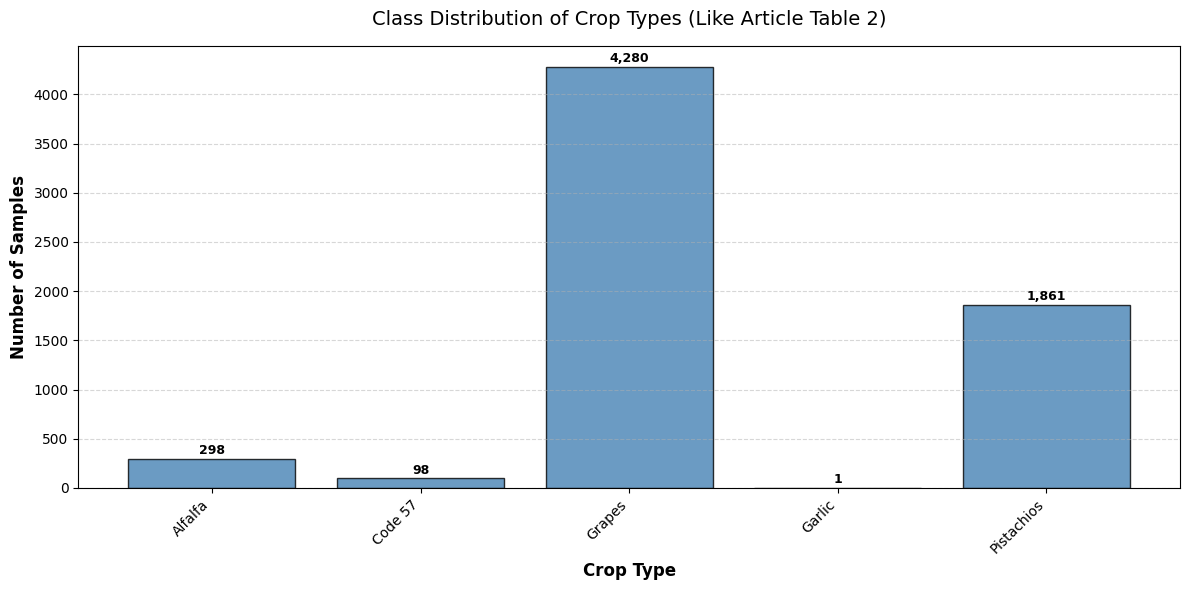


✅ Saved: outputs/figures/class_distribution.png


In [82]:
print("\n" + "="*60)
print("STEP 2: CLASS DISTRIBUTION (Like Article Table 2)")
print("="*60)

# 1. Mapping for professional names (Central Valley California)
CROP_NAMES = {
    1: "Corn", 24: "Winter Wheat", 36: "Alfalfa", 61: "Fallow/Idle", 
    66: "Cherries", 69: "Grapes", 72: "Onions", 74: "Garlic", 
    75: "Almonds", 76: "Walnuts", 176: "Grass/Pasture", 204: "Pistachios"
}

unique, counts = np.unique(y, return_counts=True)

# 2. Text Table Output (Formatted to match your image)
print("\nClass Distribution:")
print(f"{'Crop Name':<20} {'Code':<8} {'Count':<12} {'Percentage':<12}")
print("-" * 60)

for code, count in zip(unique, counts):
    name = CROP_NAMES.get(code, f"Other ({code})")
    print(f"{name:<20} {code:<8} {count:<12,} {100*count/len(y):<12.1f}%")

print("-" * 60)
print(f"{'TOTAL':<20} {'':<8} {len(y):<12,} {100.0:<12.1f}%")

# 3. Bar Chart Output
plt.figure(figsize=(12, 6))

# Map codes to labels for the chart
labels = [CROP_NAMES.get(code, f"Code {code}") for code in unique]

bars = plt.bar(range(len(unique)), counts, color='steelblue', edgecolor='black', alpha=0.8)

# Format X-axis with Names and 45-degree rotation
plt.xticks(range(len(unique)), labels, rotation=45, ha='right', fontsize=10)
plt.xlabel("Crop Type", fontsize=12, fontweight='bold')
plt.ylabel("Number of Samples", fontsize=12, fontweight='bold')
plt.title("Class Distribution of Crop Types (Like Article Table 2)", fontsize=14, pad=15)

# Add value labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15, 
             f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("outputs/figures/class_distribution.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/class_distribution.png")

STEP 3: NDVI CALCULATION FUNCTION


STEP 3: NDVI TIME-SERIES PROFILES (Like Article Figure 2)
  Alfalfa             : 100 samples used for curves
  Code 57             : 98 samples used for curves
  Grapes              : 100 samples used for curves
  Garlic              : 1 samples used for curves
  Pistachios          : 100 samples used for curves


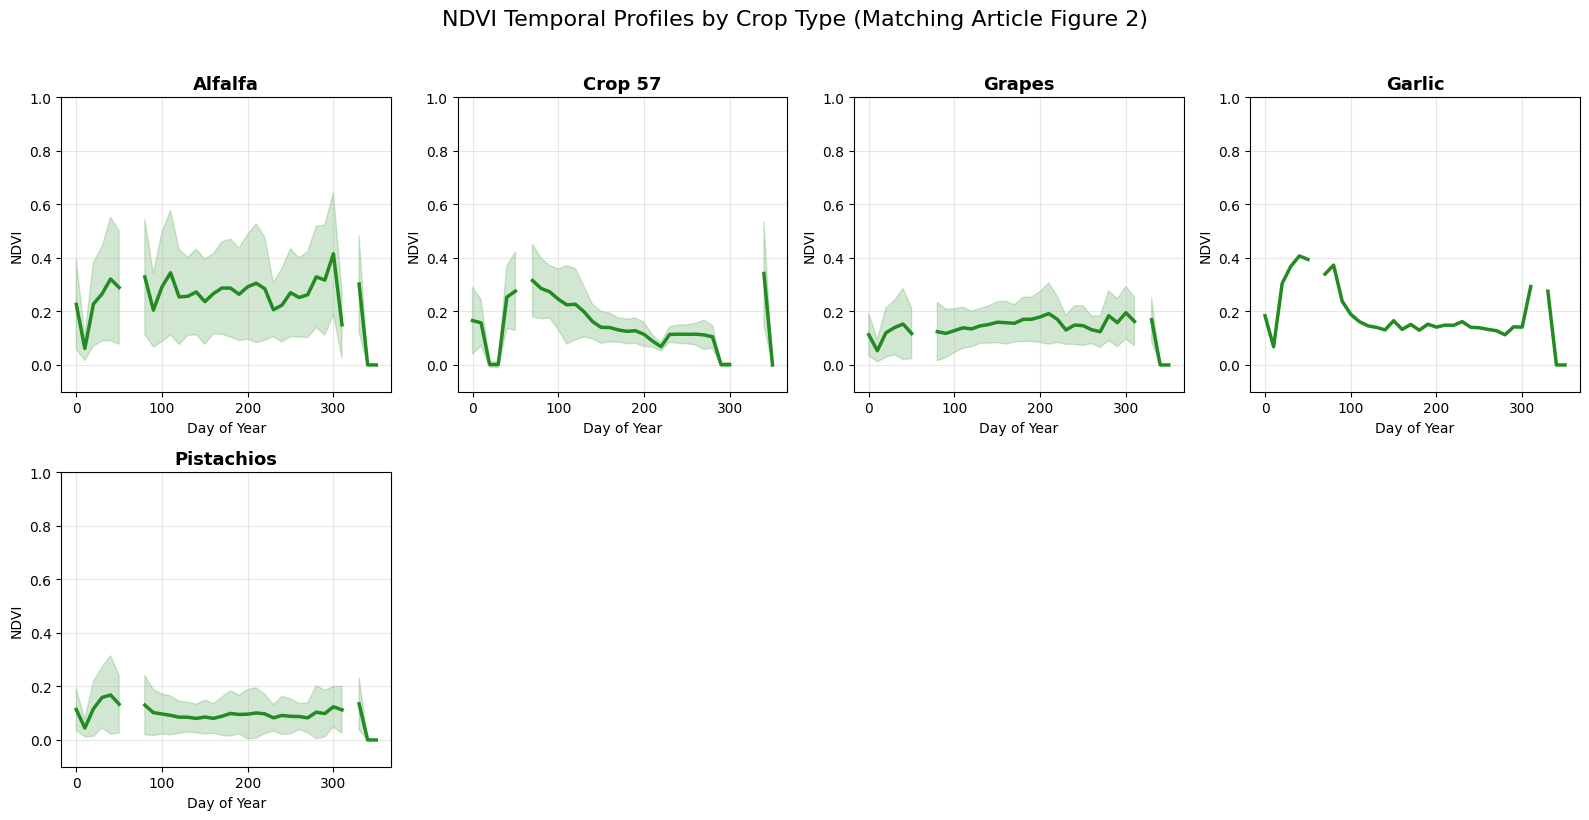


✅ Saved: outputs/figures/ndvi_profiles.png


In [83]:
print("\n" + "="*60)
print("STEP 3: NDVI TIME-SERIES PROFILES (Like Article Figure 2)")
print("="*60)

# 1. Group samples by crop code
crop_ndvi = {}

for crop_code in unique:
    indices = np.where(y == crop_code)[0]
    crop_ndvi[crop_code] = []
    # Take up to 100 samples per crop for visualization
    n_samples = min(100, len(indices))
    for idx in indices[:n_samples]:
        ndvi = calculate_ndvi(X[idx])
        crop_ndvi[crop_code].append(ndvi)
    
    # Get the name for printing
    name = CROP_NAMES.get(crop_code, f"Code {crop_code}")
    print(f"  {name:<20}: {len(crop_ndvi[crop_code])} samples used for curves")

time_steps = np.arange(36) * 10  # 10-day intervals

# 2. Determine grid size for subplots
n_crops = len(unique)
n_cols = min(4, n_crops)
n_rows = (n_crops + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten() if n_crops > 1 else [axes]

# 3. Plotting the Curves
for idx, (crop_code, ndvi_list) in enumerate(crop_ndvi.items()):
    if idx >= len(axes): break
    
    mean_ndvi = np.mean(ndvi_list, axis=0)
    std_ndvi = np.std(ndvi_list, axis=0)
    
    # Plot mean curve (Thick green line)
    axes[idx].plot(time_steps, mean_ndvi, color='forestgreen', linewidth=2.5, label='Mean NDVI')
    
    # Plot confidence interval (Shaded area matching the paper)
    axes[idx].fill_between(time_steps, 
                           mean_ndvi - std_ndvi, 
                           mean_ndvi + std_ndvi, 
                           alpha=0.2, color='forestgreen')
    
    # --- KEY UPDATE: Use Names in Titles ---
    crop_label = CROP_NAMES.get(crop_code, f"Crop {crop_code}")
    axes[idx].set_title(f"{crop_label}", fontsize=13, fontweight='bold')
    
    axes[idx].set_xlabel("Day of Year", fontsize=10)
    axes[idx].set_ylabel("NDVI", fontsize=10)
    axes[idx].set_ylim(-0.1, 1.0)
    axes[idx].grid(True, alpha=0.3)

# Hide unused subplots
for idx in range(len(crop_ndvi), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle("NDVI Temporal Profiles by Crop Type (Matching Article Figure 2)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("outputs/figures/ndvi_profiles.png", dpi=300)
plt.show()

print("\n✅ Saved: outputs/figures/ndvi_profiles.png")

STEP 4: NDVI TIME-SERIES PROFILES (Like Article Figure 2)


STEP 4: TEMPORAL PATTERNS (Paper-style)
  Grapes              : 100 samples used for NDVI curves
  Alfalfa             : 100 samples used for NDVI curves
  Pistachios          : 100 samples used for NDVI curves
  Others              : 99 samples used for NDVI curves


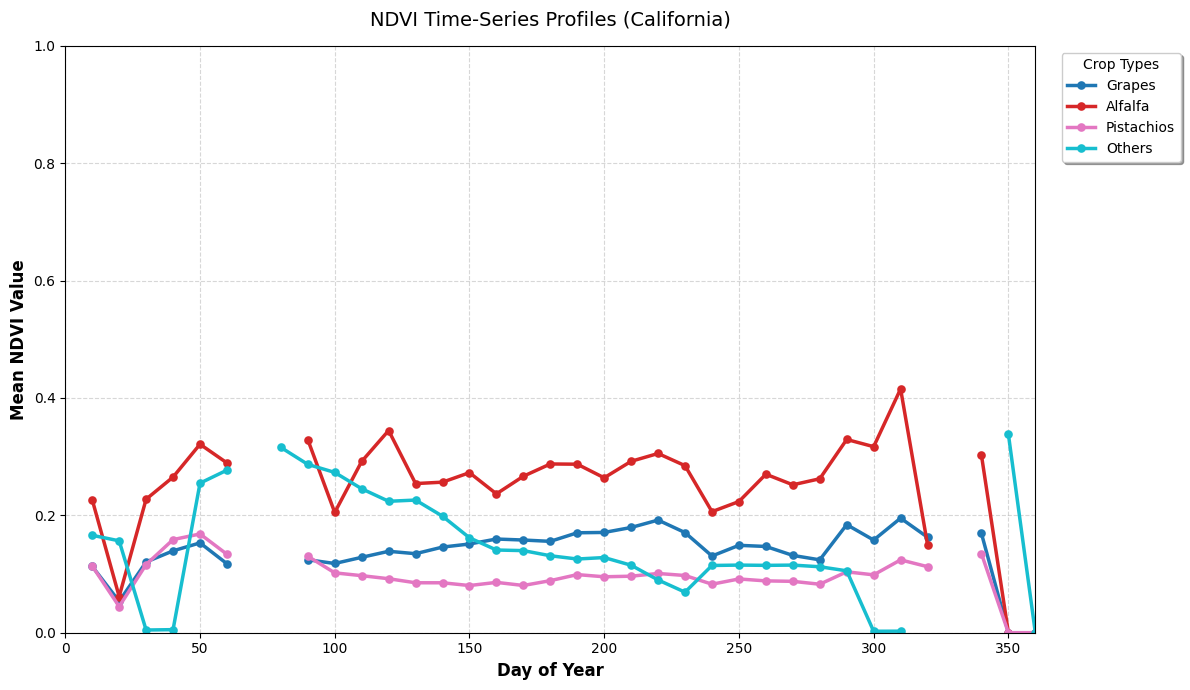


✅ Saved: outputs/figures/temporal_patterns.png


In [94]:
# ============================================================
# STEP 4: TEMPORAL PATTERNS (Paper-style NDVI curves)
# ============================================================

print("\n" + "="*60)
print("STEP 4: TEMPORAL PATTERNS (Paper-style)")
print("="*60)

# ---- 1. Select crops like in the paper ----
SELECTED_CROPS = {
    69: "Grapes",
    75: "Almonds",
    36: "Alfalfa",
    204: "Pistachios"
}

crop_ndvi = {}

# ---- 2. Compute NDVI for selected crops ----
for crop_code in SELECTED_CROPS.keys():
    indices = np.where(y == crop_code)[0]
    
    if len(indices) == 0:
        continue
        
    subset = indices[:min(100, len(indices))]
    ndvi_list = [calculate_ndvi(X[i]) for i in subset]
    crop_ndvi[crop_code] = ndvi_list

# ---- 3. Add "Others" category ----
other_indices = np.where(~np.isin(y, list(SELECTED_CROPS.keys())))[0]

if len(other_indices) > 0:
    subset = other_indices[:min(100, len(other_indices))]
    crop_ndvi["Others"] = [calculate_ndvi(X[i]) for i in subset]

# ---- 4. Plot ----
plt.figure(figsize=(12, 7))

time_steps = np.arange(1, 37) * 10
colors = plt.cm.tab10(np.linspace(0, 1, len(crop_ndvi)))

for idx, (crop_code, ndvi_list) in enumerate(crop_ndvi.items()):
    mean_ndvi = np.mean(ndvi_list, axis=0)
    
    if crop_code == "Others":
        name = "Others"
    else:
        name = SELECTED_CROPS[crop_code]
    
    print(f"  {name:<20}: {len(ndvi_list)} samples used for NDVI curves")
    
    plt.plot(
        time_steps,                  # ✅ FIXED
        mean_ndvi,                  # ✅ FIXED
        linewidth=2.5,
        color=colors[idx],
        marker='o',
        markersize=5,
        markerfacecolor=colors[idx],   # same as line
        markeredgecolor=colors[idx],   # same as line
        markeredgewidth=1.2,
        label=name
    )

# ---- 5. Styling ----
plt.xlabel("Day of Year", fontsize=12, fontweight='bold')
plt.ylabel("Mean NDVI Value", fontsize=12, fontweight='bold')
plt.title("NDVI Time-Series Profiles (California)", fontsize=14, pad=15)

plt.ylim(0, 1)
plt.xlim(0, 360)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left',
           title="Crop Types", fontsize=10, shadow=True)

plt.tight_layout()

plt.savefig("outputs/figures/temporal_patterns.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Saved: outputs/figures/temporal_patterns.png")


STEP 5: MISSING VALUES INSPECTION (Like Article Figure 15)


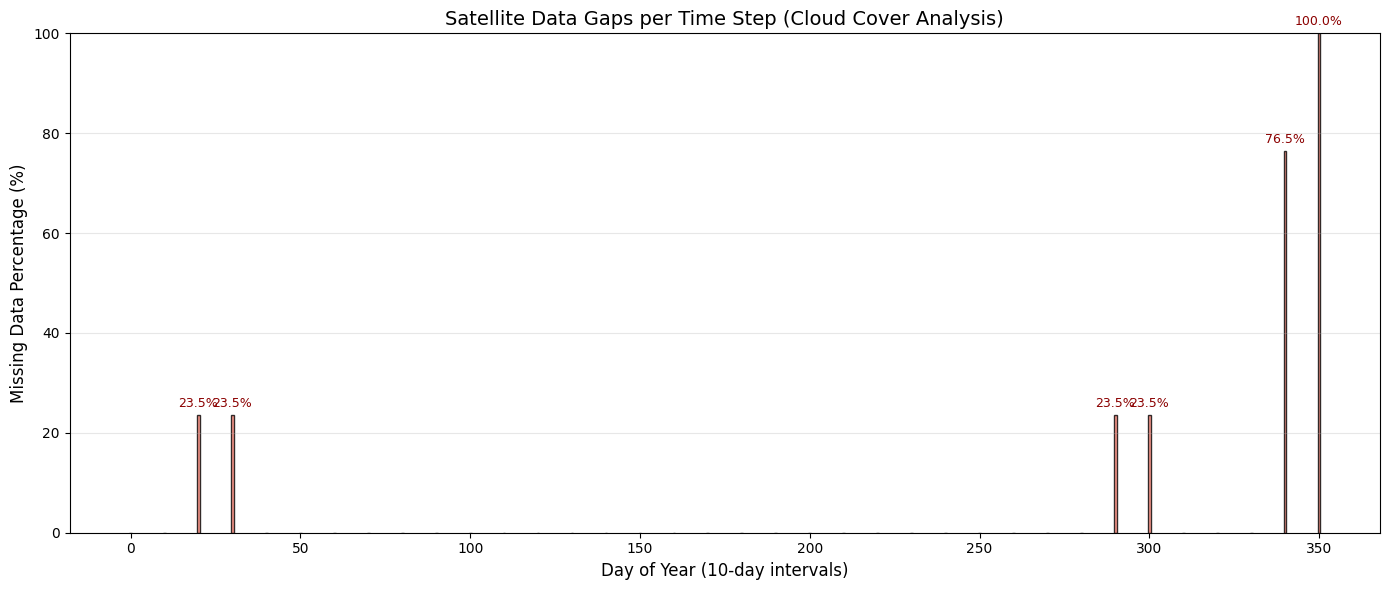

✅ Saved: outputs/figures/missing_values.png


In [85]:
print("\n" + "="*60)
print("STEP 5: MISSING VALUES INSPECTION (Like Article Figure 15)")
print("="*60)

# Calculate missing rate: 1 - mean of masks (where 1=data, 0=missing)
missing_per_time = 100 * (1 - masks.mean(axis=(0, 2)))

plt.figure(figsize=(14, 6))
# Using 'salmon' color to highlight data gaps
bars = plt.bar(time_steps, missing_per_time, color='salmon', edgecolor='black', alpha=0.8)

plt.xlabel("Day of Year (10-day intervals)", fontsize=12)
plt.ylabel("Missing Data Percentage (%)", fontsize=12)
plt.title("Satellite Data Gaps per Time Step (Cloud Cover Analysis)", fontsize=14)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')

# Add labels for steps with high missing data (>10%)
for bar, missing in zip(bars, missing_per_time):
    if missing > 10:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{missing:.1f}%', ha='center', va='bottom', fontsize=9, color='darkred')

plt.tight_layout()
plt.savefig("outputs/figures/missing_values.png", dpi=300)
plt.show()
print("✅ Saved: outputs/figures/missing_values.png")

STEP 5: Interactive Location Verification

In [86]:

import folium
import webbrowser

# Calculate the center of the extracted samples (average of the first tile's bounds)
center_lat, center_lon = 36.7, -119.8 # Central Valley center

m = folium.Map(location=[center_lat, center_lon], zoom_start=7)

# Add a marker for the North Region (Sacramento) and South Region (Fresno)
folium.Marker([38.5, -121.5], popup="North California Tiles (4)", icon=folium.Icon(color='blue')).add_to(m)
folium.Marker([36.5, -119.5], popup="South California Tiles (4)", icon=folium.Icon(color='green')).add_to(m)

# Save and open
m.save('outputs/figures/map_check.html')
print("✅ Created interactive map: outputs/figures/map_check.html")

✅ Created interactive map: outputs/figures/map_check.html


STEP 6: MISSING VALUES INSPECTION (Like Article Figure 15)

In [87]:
import folium
from folium import plugins

print("\n" + "="*60)
print("STEP 6: REGIONAL COVERAGE MAP")
print("="*60)

# Center the map between Sacramento (North) and Fresno (South)
m = folium.Map(location=[37.5, -120.5], zoom_start=6, tiles='CartoDB positron')

# Marker for North California (Sacramento Valley)
folium.Marker(
    [38.5816, -121.4944], 
    popup="North Region: 4 Sentinel Tiles", 
    icon=folium.Icon(color='blue', icon='leaf')
).add_to(m)

# Marker for South Region (San Joaquin Valley)
folium.Marker(
    [36.7378, -119.7871], 
    popup="South Region: 4 Sentinel Tiles", 
    icon=folium.Icon(color='green', icon='leaf')
).add_to(m)

# Save the map as HTML
map_file = "outputs/figures/location_check.html"
m.save(map_file)
print(f"✅ Created interactive map: {map_file}")
# Note: You can open this file in your browser to see the 8-tile locations.


STEP 6: REGIONAL COVERAGE MAP
✅ Created interactive map: outputs/figures/location_check.html


STEP 7: summary report

In [88]:
print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("="*60)

print(f"📊 TOTAL SAMPLES:     {len(y):,}")
print(f"🌾 CROP CLASSES:      {len(unique)}")
print(f"⏳ TIME STEPS:        36 (Full year)")
print(f"📡 SPECTRAL BANDS:    10 (B2-B12)")
print(f"☁️ AVG MISSING DATA:   {missing_per_time.mean():.2f}%")

print("\n" + "-"*30)
print("Notebook 2 Complete. All visualizations are saved in 'outputs/figures/'.")
print("You are now ready to train the Neural Network in Notebook 3.")
print("-"*30)


EXPLORATORY DATA ANALYSIS - FINAL SUMMARY
📊 TOTAL SAMPLES:     6,538
🌾 CROP CLASSES:      5
⏳ TIME STEPS:        36 (Full year)
📡 SPECTRAL BANDS:    10 (B2-B12)
☁️ AVG MISSING DATA:   7.52%

------------------------------
Notebook 2 Complete. All visualizations are saved in 'outputs/figures/'.
You are now ready to train the Neural Network in Notebook 3.
------------------------------
